0. Setup Awal

In [1]:
import os
import time
import tracemalloc
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    StandardScaler,
    normalize
)

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid'
    in plt.style.available
    else 'default'
)

plt.rcParams['figure.dpi'] = 120

OUTPUT_DIR = 'outputKmeansCosine'
os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

1. Data Understanding

1.1 Load Dataset

In [2]:
df = pd.read_csv('burnout_dataset1.csv')

print(f'Jumlah data awal: {len(df)}')

# df = df.sample(
#     n=5000,
#     random_state=42
# ).reset_index(drop=True)
# print(f'Jumlah data setelah sampling: {len(df)}')

Jumlah data awal: 50000


1.2 Data Preview

In [3]:
print("5 Baris Pertama Dataset:")
display(df.head())

print("\nNama Semua Kolom:")
print(df.columns.tolist())

5 Baris Pertama Dataset:


,Person_ID,Age,Gender,Country,Occupation,Education_Level,Employment_Status,Monthly_Income_USD,Work_Hours_Per_Week,Remote_Work,...,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score,Mental_Health_Status,AI_Wellness_Recommendation,Burnout_Risk
0,1,58.0,Male,United States,Marketing Manager,Diploma,Employed,2786.0,67,Hybrid,...,No,Yes,Average,6.0,19.0,2,82,Critical,Practice Mindfulness,High
1,2,24.0,Female,Pakistan,Freelancer,Bachelor,Student,8027.0,44,Hybrid,...,Yes,No,Good,4.0,27.0,22,64,Critical,Reduce Workload,Moderate
2,3,59.0,Male,Malaysia,Accountant,PhD,Employed,3177.0,60,No,...,Yes,No,Average,4.0,51.0,17,50,Needs Attention,Increase Physical Activity,Moderate
3,4,65.0,Other,Mexico,Chef,Master,Self-Employed,4093.0,25,Yes,...,No,Yes,Good,7.0,83.0,14,16,Healthy,Maintain Healthy Routine,Low
4,5,64.0,Other,Japan,Farmer,Diploma,Student,NaN,52,No,...,Yes,No,Poor,9.0,61.0,4,26,Healthy,Reduce Workload,Low



Nama Semua Kolom:
['Person_ID', 'Age', 'Gender', 'Country', 'Occupation', 'Education_Level', 'Employment_Status', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Sleep_Quality', 'Stress_Level', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Exercise_Frequency', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet', 'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance', 'Support_System', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days', 'Burnout_Score', 'Mental_Health_Status', 'AI_Wellness_Recommendation', 'Burnout_Risk']


1.3 Tipe data dan Missing Values

In [4]:
print('Tipe Data:')
print(df.dtypes)

print('\nJumlah Missing Value:')
missing = df.isnull().sum()

missing[missing > 0]

Tipe Data:
Person_ID                          int64
Age                              float64
Gender                               str
Country                              str
Occupation                           str
Education_Level                      str
Employment_Status                    str
Monthly_Income_USD               float64
Work_Hours_Per_Week                int64
Remote_Work                          str
Job_Satisfaction                 float64
Work_Life_Balance                float64
Sleep_Hours                      float64
Sleep_Quality                        str
Stress_Level                         str
Anxiety_Score                    float64
Depression_Score                 float64
Mood_Score                       float64
Emotional_Stability                int64
Physical_Activity_Hours          float64
Exercise_Frequency                   str
Meditation_Minutes               float64
Screen_Time_Hours                float64
Social_Media_Hours               float64
Gamin

Age                         250
Monthly_Income_USD         1450
Job_Satisfaction            500
Work_Life_Balance           650
Sleep_Hours                 950
Anxiety_Score               800
Depression_Score            850
Mood_Score                  900
Physical_Activity_Hours    1100
Meditation_Minutes         1200
Screen_Time_Hours           850
Social_Media_Hours          600
Gaming_Hours                750
Therapy_Attendance          400
Life_Satisfaction           700
Productivity_Score          950
dtype: int64

1.4 Identifikasi Kolom yang Digunakan

In [5]:
# Kolom numerik asli
numeric_columns = df.select_dtypes(include='number').columns

# Kolom kategorikal yang akan di-encoding
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

print('Kolom Numerik:')
print(numeric_columns.tolist())

print('\nKolom Kategorikal yang akan di-encoding:')
print(categorical_columns)

Kolom Numerik:
['Person_ID', 'Age', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days', 'Burnout_Score']

Kolom Kategorikal yang akan di-encoding:
Index(['Gender', 'Country', 'Occupation', 'Education_Level',
       'Employment_Status', 'Remote_Work', 'Sleep_Quality', 'Stress_Level',
       'Exercise_Frequency', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet',
       'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance',
       'Support_System', 'Mental_Health_Status', 'AI_Wellness_Recommendation',
       'Burnout_Risk'],
      dtype='str')


1.5 Statistik Deskriptif

In [6]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Person_ID,50000.0,25000.500000,14433.901067,1.0,12500.75,25000.5,37500.25,50000.0
Age,49750.0,41.448181,13.871634,18.0,29.00,41.0,53.00,65.0
Monthly_Income_USD,48550.0,6251.281524,3319.661435,500.0,3381.00,6231.0,9134.00,12000.0
Work_Hours_Per_Week,50000.0,44.946160,14.729024,20.0,32.00,45.0,58.00,70.0
Job_Satisfaction,49500.0,5.499051,2.866621,1.0,3.00,6.0,8.00,10.0
Work_Life_Balance,49350.0,5.504397,2.867492,1.0,3.00,6.0,8.00,10.0
Sleep_Hours,49050.0,6.997445,1.728766,4.0,5.50,7.0,8.50,10.0
Anxiety_Score,49200.0,40.449045,26.004291,0.0,19.00,39.0,59.00,100.0
Depression_Score,49150.0,40.601160,26.308933,0.0,19.00,39.0,60.00,100.0
Mood_Score,49100.0,59.622994,25.783486,0.0,41.00,61.0,80.00,100.0


1.6 Visualisasi Distribusi Data

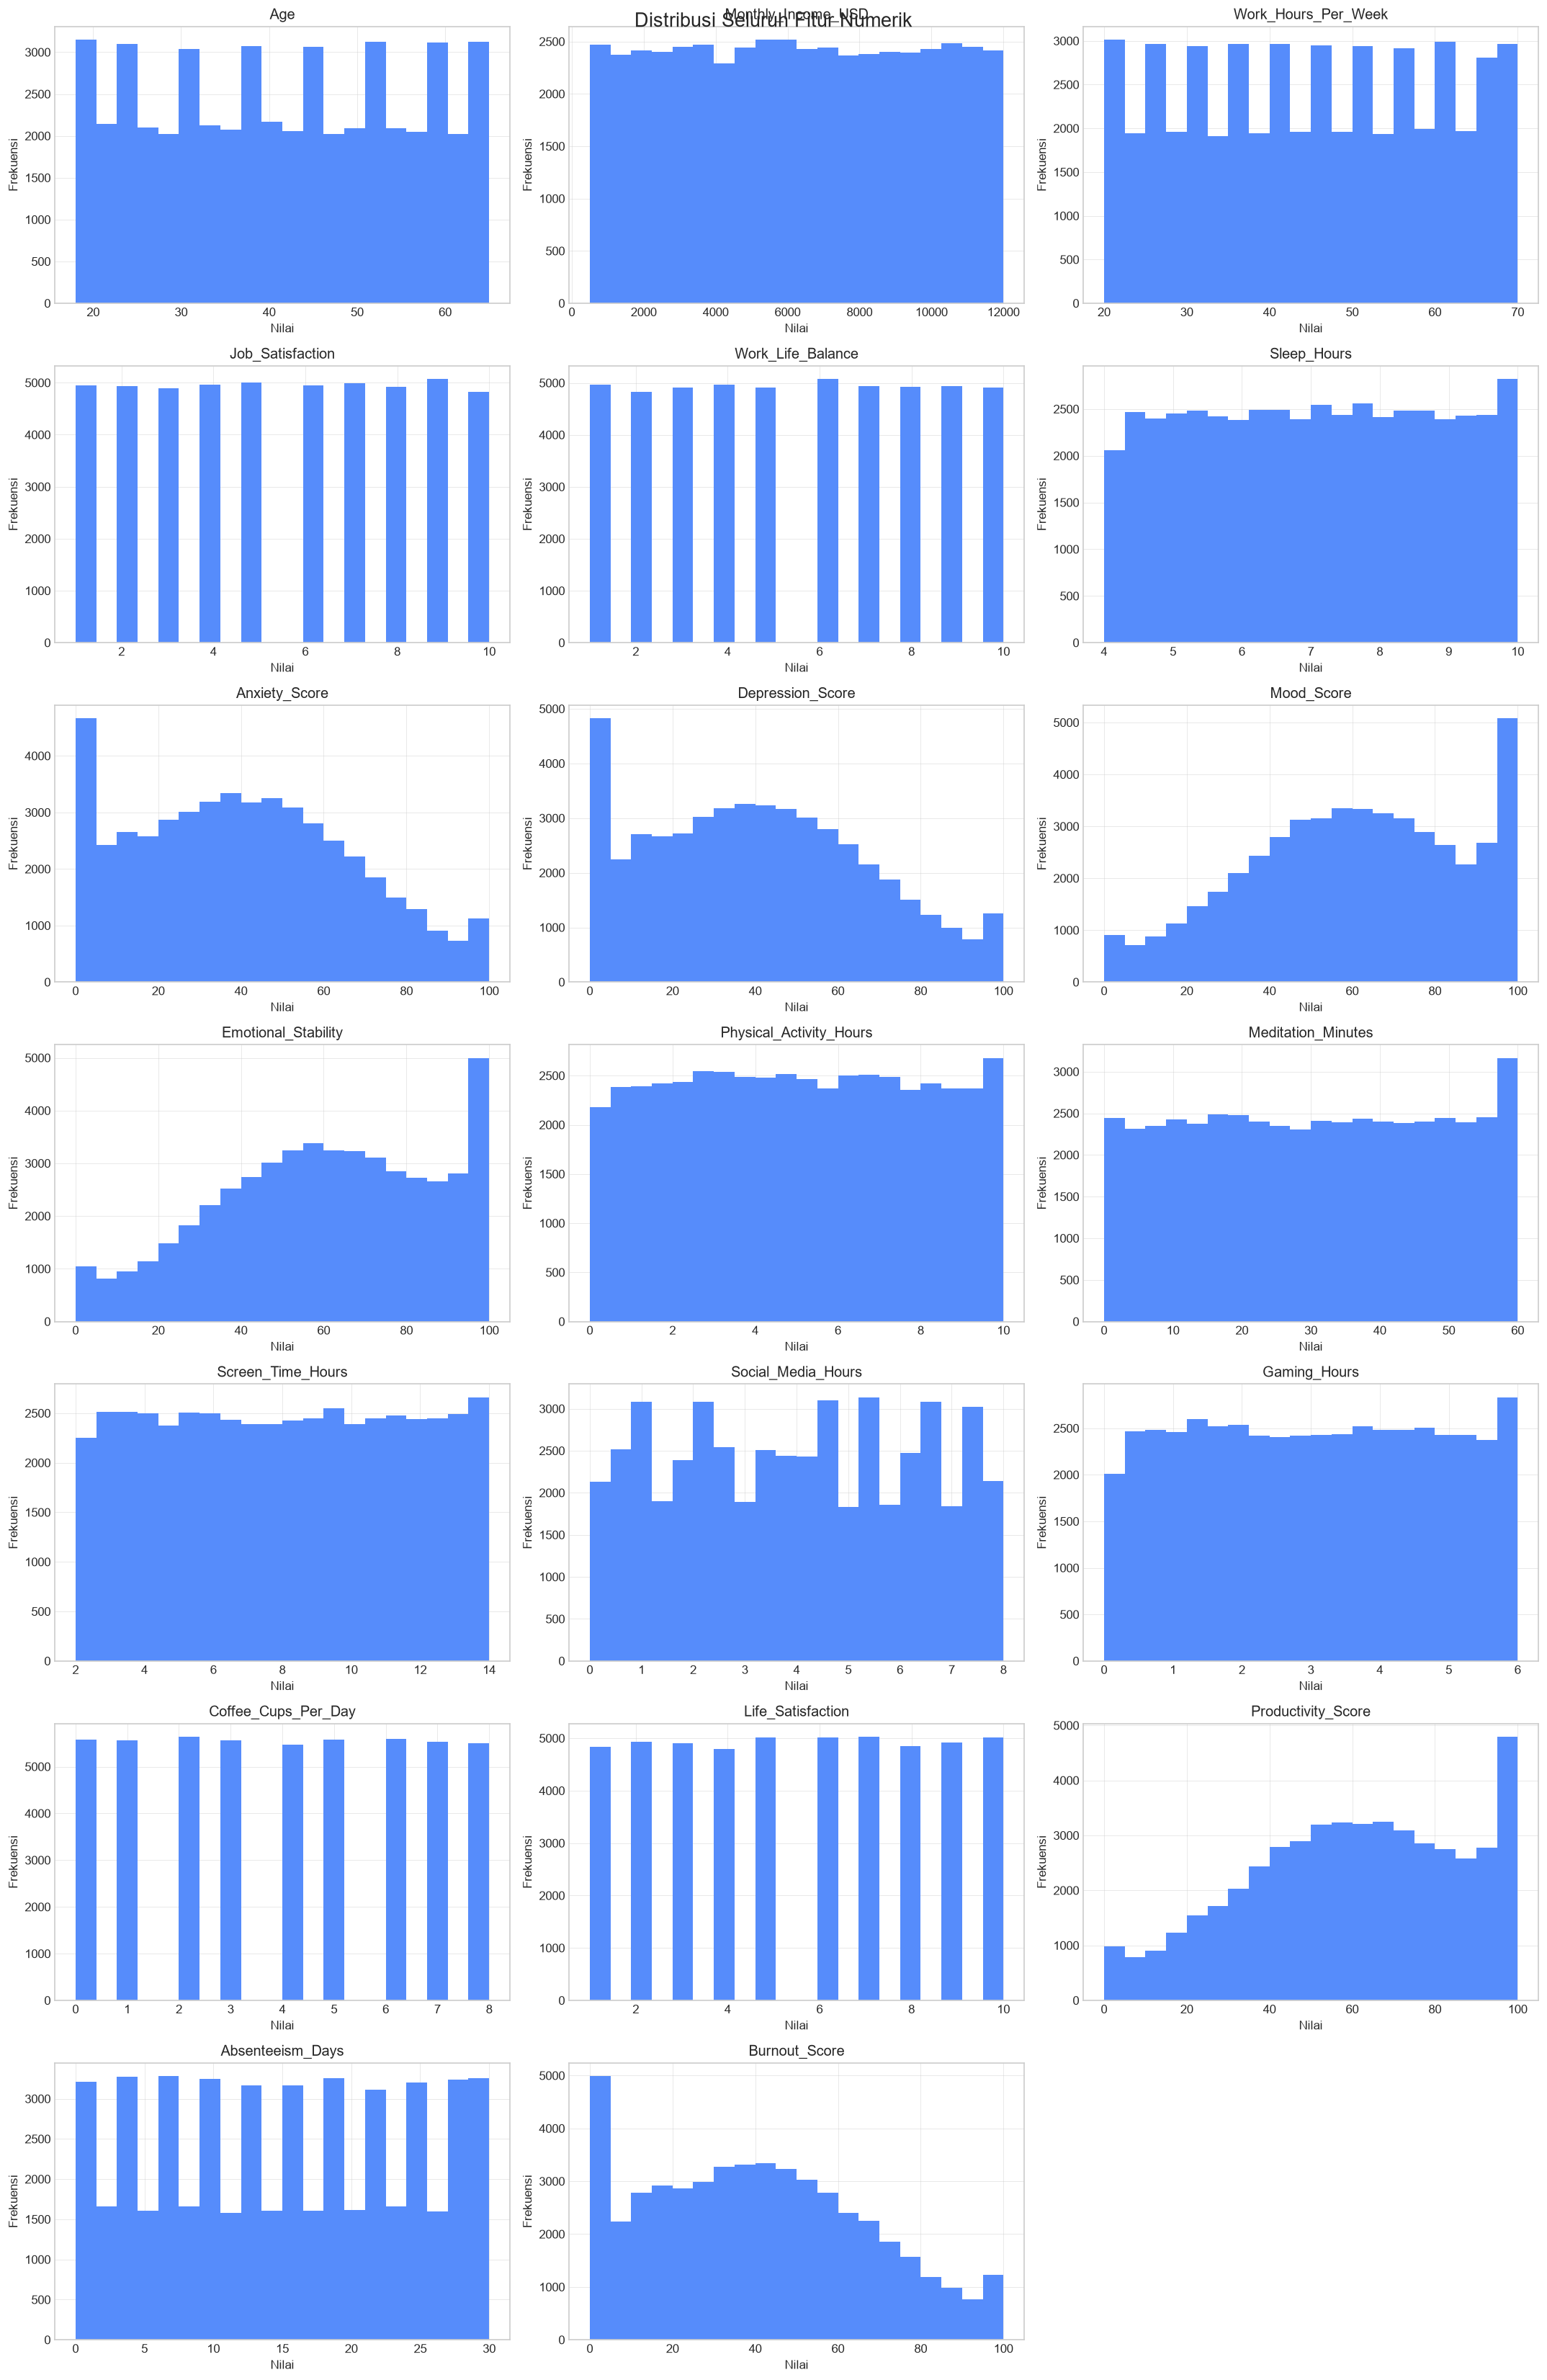

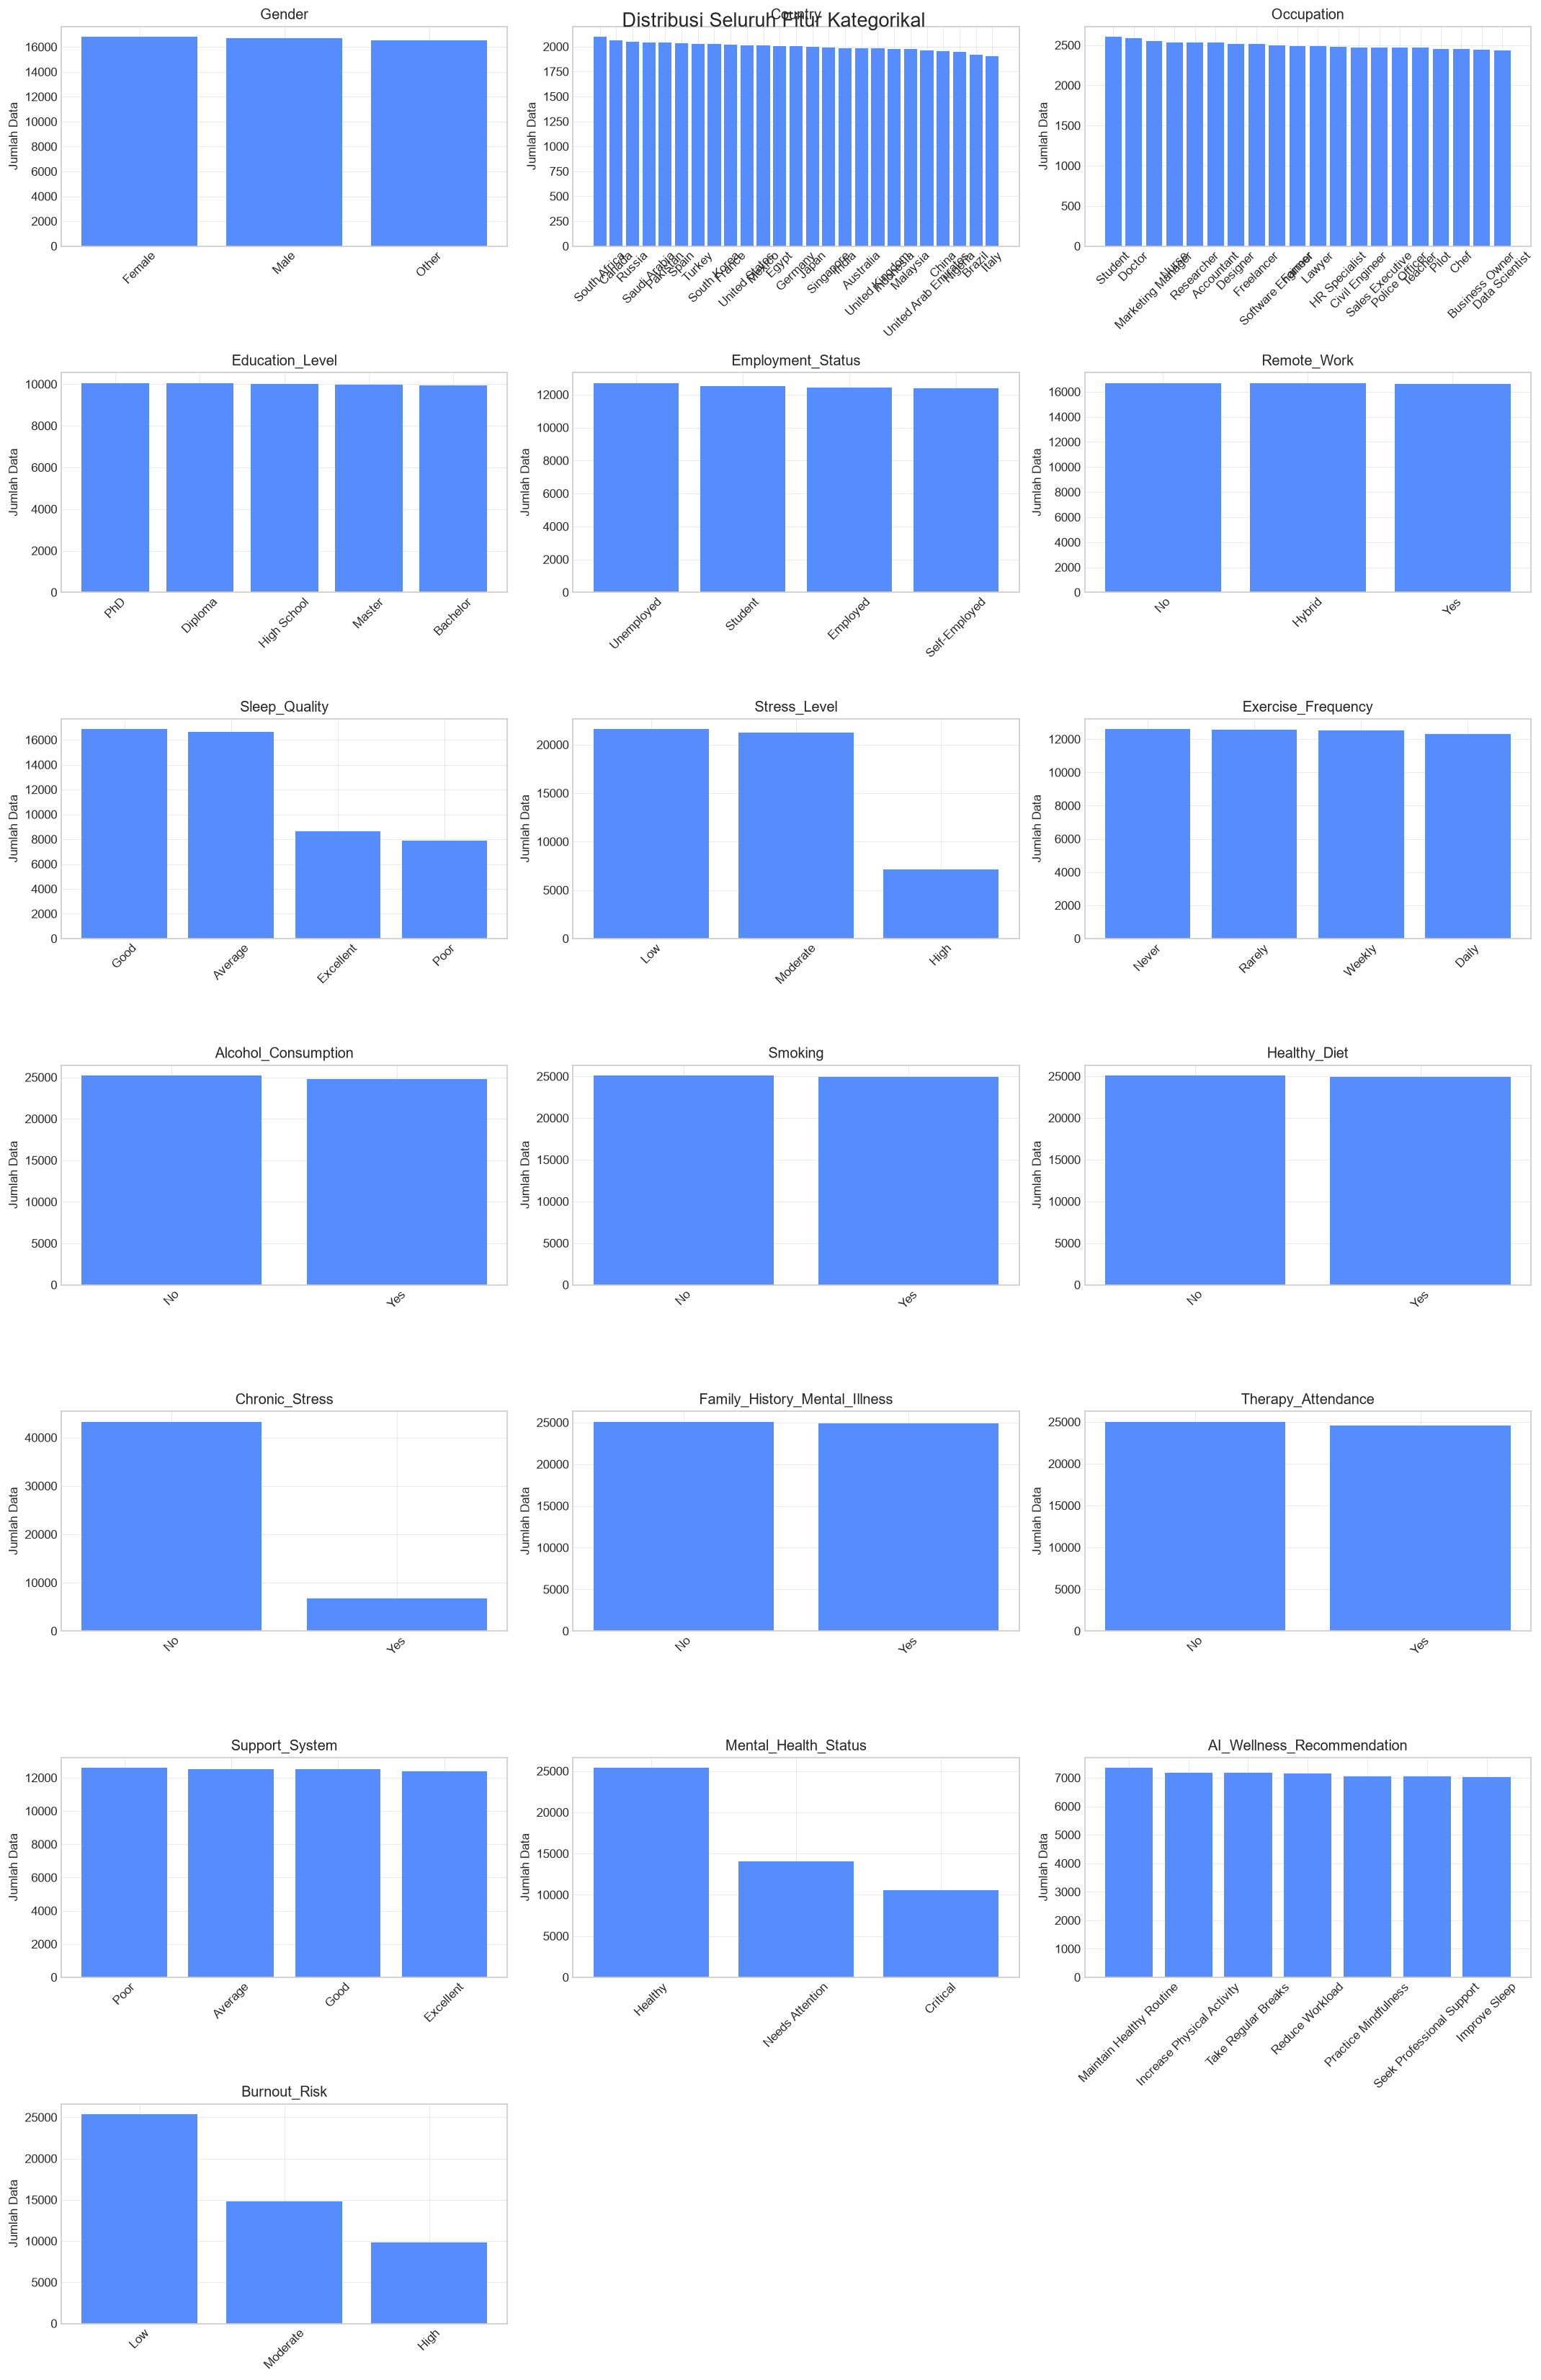

In [7]:
# FITUR NUMERIK
numeric_columns = df.select_dtypes(
    include='number'
).columns

numeric_columns = numeric_columns.drop(
    ['Person_ID'],
    errors='ignore'
)

n_features = len(numeric_columns)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, n_rows * 4)
)

axes = axes.flatten()

for i, column in enumerate(numeric_columns):

    axes[i].hist(
        df[column].dropna(),
        bins=20
    )

    axes[i].set_title(column)
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

for i in range(n_features, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle(
    'Distribusi Seluruh Fitur Numerik',
    fontsize=16
)

plt.tight_layout()
plt.show()


# FITUR KATEGORIKAL
n_features = len(categorical_columns)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, n_rows * 4)
)

axes = axes.flatten()

for i, column in enumerate(categorical_columns):

    counts = df[column].value_counts()

    axes[i].bar(
        counts.index.astype(str),
        counts.values
    )

    axes[i].set_title(column)
    axes[i].set_ylabel('Jumlah Data')
    axes[i].tick_params(
        axis='x',
        rotation=45
    )

for i in range(n_features, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle(
    'Distribusi Seluruh Fitur Kategorikal',
    fontsize=16
)

plt.tight_layout()
plt.show()

1.7 Visualisasi Deteksi Outlier

In [8]:
numeric_data = df[numeric_columns]

Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (numeric_data < lower_bound) |
    (numeric_data > upper_bound)
)

In [9]:
outlier_summary = pd.DataFrame({
    'Jumlah Outlier': outlier_mask.sum(),
    'Persentase (%)': (
        outlier_mask.sum() / len(df) * 100
    ).round(2)
})

outlier_summary = outlier_summary.sort_values(
    'Jumlah Outlier',
    ascending=False
)

outlier_summary

,Jumlah Outlier,Persentase (%)
Age,0,0.0
Monthly_Income_USD,0,0.0
Work_Hours_Per_Week,0,0.0
Job_Satisfaction,0,0.0
Work_Life_Balance,0,0.0
Sleep_Hours,0,0.0
Anxiety_Score,0,0.0
Depression_Score,0,0.0
Mood_Score,0,0.0
Emotional_Stability,0,0.0


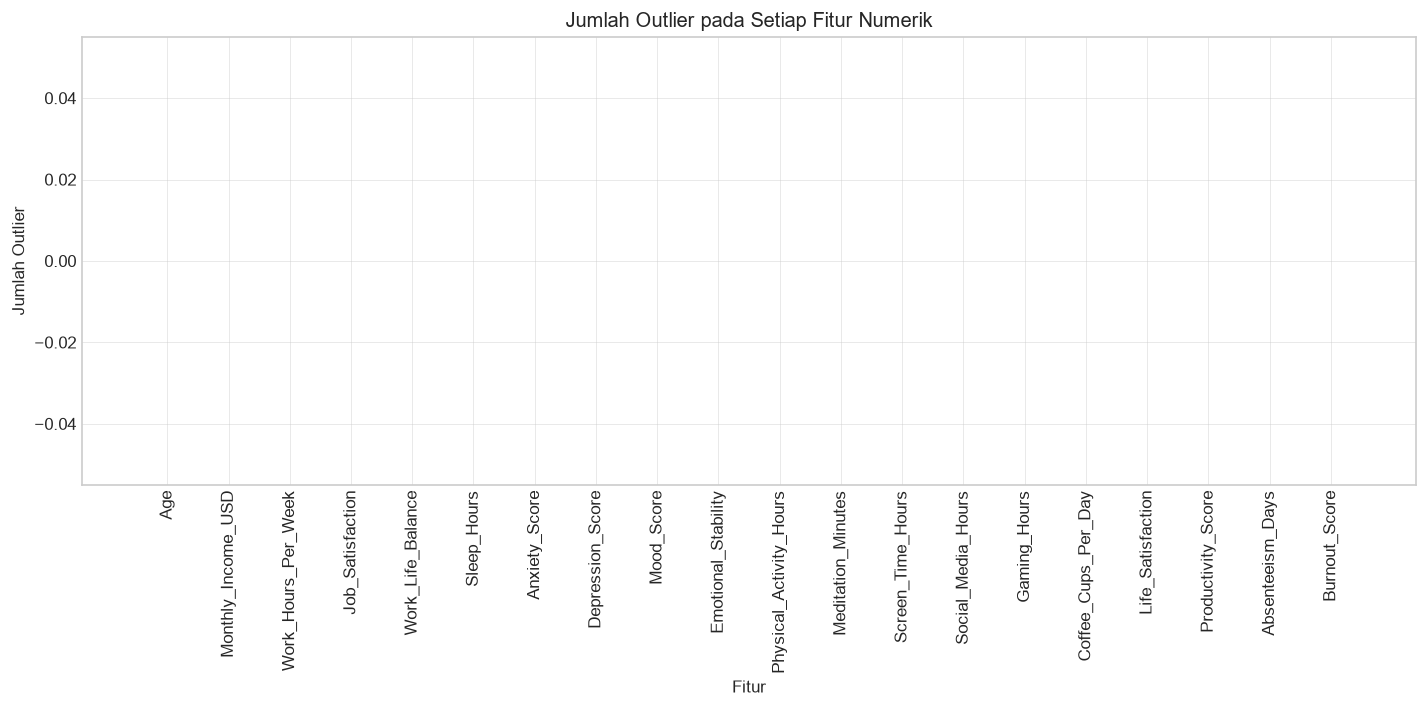

In [10]:
plt.figure(figsize=(12, 6))

plt.bar(
    outlier_summary.index,
    outlier_summary['Jumlah Outlier']
)

plt.title('Jumlah Outlier pada Setiap Fitur Numerik')
plt.xlabel('Fitur')
plt.ylabel('Jumlah Outlier')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [11]:
print(outlier_summary)

                         Jumlah Outlier  Persentase (%)
Age                                   0             0.0
Monthly_Income_USD                    0             0.0
Work_Hours_Per_Week                   0             0.0
Job_Satisfaction                      0             0.0
Work_Life_Balance                     0             0.0
Sleep_Hours                           0             0.0
Anxiety_Score                         0             0.0
Depression_Score                      0             0.0
Mood_Score                            0             0.0
Emotional_Stability                   0             0.0
Physical_Activity_Hours               0             0.0
Meditation_Minutes                    0             0.0
Screen_Time_Hours                     0             0.0
Social_Media_Hours                    0             0.0
Gaming_Hours                          0             0.0
Coffee_Cups_Per_Day                   0             0.0
Life_Satisfaction                     0         

2.1 Seleksi Kolom

In [12]:
# Drop beberapa kolom yang tidak perlu
numeric_columns = numeric_columns.drop(
    ['Burnout_Score'],
    errors='ignore'
)

categorical_columns = categorical_columns.drop(
    ['Gender', 'Country', 'Occupation', 'AI_Wellness_Recommendation', 'Burnout_Risk', 'Education_Level', 'Employment_Status'],
    errors='ignore'
)

# Menggabungkan
selected_columns = list(numeric_columns) + list(categorical_columns)

X = df[selected_columns].copy()

X.head()

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,58.0,2786.0,67,3.0,7.0,4.6,74.0,75.0,26.0,18,...,High,Weekly,Yes,Yes,No,Yes,No,Yes,Average,Critical
1,24.0,8027.0,44,5.0,8.0,4.7,58.0,80.0,29.0,37,...,Moderate,Weekly,Yes,Yes,Yes,No,Yes,No,Good,Critical
2,59.0,3177.0,60,8.0,7.0,6.3,54.0,55.0,44.0,48,...,Moderate,Daily,Yes,No,No,No,Yes,No,Average,Needs Attention
3,65.0,4093.0,25,2.0,9.0,7.1,12.0,11.0,88.0,80,...,Low,Weekly,Yes,No,No,No,No,Yes,Good,Healthy
4,64.0,NaN,52,1.0,4.0,9.1,25.0,48.0,67.0,76,...,Low,Never,Yes,No,No,No,Yes,No,Poor,Healthy


2.2 Encoding Data Kategorikal

In [13]:
encoding_maps = {
    'Remote_Work': {
        'No': 0,
        'Hybrid': 1,
        'Yes': 2
    },

    'Sleep_Quality': {
        'Excellent': 0,
        'Good': 1,
        'Average': 2,
        'Poor': 3
    },

    'Stress_Level': {
        'Low': 0,
        'Moderate': 1,
        'High': 2
    },

    'Exercise_Frequency': {
        'Daily': 0,
        'Weekly': 1,
        'Rarely': 2,
        'Never': 3
    },

    'Alcohol_Consumption': {
        'No': 0,
        'Yes': 1
    },

    'Smoking': {
        'No': 0,
        'Yes': 1
    },

    'Healthy_Diet': {
        'No': 1,
        'Yes': 0
    },

    'Chronic_Stress': {
        'No': 0,
        'Yes': 1
    },

    'Family_History_Mental_Illness': {
        'No': 0,
        'Yes': 1
    },

    'Therapy_Attendance': {
        'No': 1,
        'Yes': 0
    },

    'Support_System': {
        'Poor': 3,
        'Average': 2,
        'Good': 1,
        'Excellent': 0
    },

    'Mental_Health_Status': {
        'Healthy': 0,
        'Needs Attention': 1,
        'Critical': 2
    }
}

for column, mapping in encoding_maps.items():
    X[column] = X[column].map(mapping)

X[categorical_columns].head()

,Remote_Work,Sleep_Quality,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1,3,2,1,1,1,1,1,0,0.0,2,2
1,1,3,1,1,1,1,0,0,1,1.0,1,2
2,0,2,1,0,1,0,1,0,1,1.0,2,1
3,2,1,0,1,1,0,1,0,0,0.0,1,0
4,0,0,0,3,1,0,1,0,1,1.0,3,0


2.3 Penanganan Missing Values

In [14]:
print('Missing value sebelum preprocessing:')
print(X.isnull().sum())

X = X.fillna(X.mean())

print('\nJumlah missing value setelah preprocessing:',)
print(X.isnull().sum())

Missing value sebelum preprocessing:
Age                               250
Monthly_Income_USD               1450
Work_Hours_Per_Week                 0
Job_Satisfaction                  500
Work_Life_Balance                 650
Sleep_Hours                       950
Anxiety_Score                     800
Depression_Score                  850
Mood_Score                        900
Emotional_Stability                 0
Physical_Activity_Hours          1100
Meditation_Minutes               1200
Screen_Time_Hours                 850
Social_Media_Hours                600
Gaming_Hours                      750
Coffee_Cups_Per_Day                 0
Life_Satisfaction                 700
Productivity_Score                950
Absenteeism_Days                    0
Remote_Work                         0
Sleep_Quality                       0
Stress_Level                        0
Exercise_Frequency                  0
Alcohol_Consumption                 0
Smoking                             0
Healthy_Diet 

2.4 Penanganan Outlier

In [15]:
# Karena tidak, tidak dilakukan

2.5 Standardisasi

In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

# L2 Normalization untuk Cosine Similarity
X_cosine = normalize(
    X_scaled,
    norm='l2',
    axis=1
)

X_cosine = pd.DataFrame(
    X_cosine,
    columns=X.columns,
    index=X.index
)

X_cosine

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,0.170403,-0.150906,0.213295,-0.124813,0.074787,-0.199457,0.185282,0.187860,-0.187461,-0.225940,...,0.261908,-0.064888,0.143653,0.142977,0.141979,0.360956,-0.141991,-0.144247,0.062960,0.232707
1,-0.234739,0.101052,-0.011958,-0.032571,0.163076,-0.249775,0.126658,0.281176,-0.223113,-0.159693,...,0.076686,-0.084794,0.187723,0.186839,-0.186772,-0.073465,0.186757,0.185319,-0.084308,0.304096
2,0.290797,-0.215450,0.234304,0.201013,0.120355,-0.093378,0.120430,0.126548,-0.140176,-0.100009,...,0.094439,-0.309747,0.231180,-0.228404,0.228487,-0.090472,0.229990,0.228219,0.101322,0.085684
3,0.313415,-0.121490,-0.249356,-0.225890,0.225941,0.011029,-0.203076,-0.208960,0.204505,0.145509,...,-0.186834,-0.083873,0.185686,-0.183456,0.183522,-0.072668,-0.183537,-0.186453,-0.083392,-0.163152
4,0.281166,0.000000,0.082617,-0.272115,-0.091101,0.211834,-0.103319,0.048933,0.049808,0.109877,...,-0.175042,0.230436,0.173966,-0.171877,0.171939,-0.068081,0.173070,0.171737,0.230620,-0.152854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,-0.082563,-0.173798,-0.027706,0.183862,0.036479,0.000313,0.134541,0.067517,-0.120009,-0.115586,...,0.086381,-0.095513,0.211455,-0.208916,-0.210383,-0.082753,0.210367,0.208746,0.092676,0.078373
49996,0.178387,0.212454,-0.225710,-0.194708,0.027612,-0.250036,-0.211961,-0.247047,0.207334,0.247086,...,-0.161043,-0.214447,0.160053,0.159299,0.158188,-0.062637,-0.158201,-0.160715,-0.213909,-0.140630
49997,-0.100755,-0.177858,0.140474,0.164124,-0.230255,0.065869,0.178148,0.268370,-0.195036,-0.189267,...,0.077108,0.250027,0.188755,-0.186489,-0.187799,-0.073869,-0.186571,-0.189535,0.250226,0.305768
49998,0.287595,-0.153701,-0.220351,-0.035612,0.106854,0.000304,-0.066665,-0.184157,0.114526,0.020422,...,-0.206517,0.271872,0.205247,0.204281,0.202856,-0.080323,-0.202872,-0.206096,0.272089,-0.180340


2.6 Data Bersih

In [17]:
print('Dimensi data setelah preprocessing:', X.shape)
print('Jumlah missing value:', X.isnull().sum().sum())

X_scaled.head()

Dimensi data setelah preprocessing: (50000, 31)
Jumlah missing value: 0


,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1.196220,-1.059350,1.497320,-0.876176,0.525001,-1.400175,1.300669,1.318767,-1.315962,-1.586087,...,1.838578,-0.455507,1.008436,1.003687,0.996685,2.53389,-0.996765,-1.012603,0.441976,1.633584
1,-1.261001,0.542844,-0.064238,-0.174969,0.876030,-1.341772,0.680397,1.510455,-1.198546,-0.857858,...,0.411952,-0.455507,1.008436,1.003687,-1.003326,-0.39465,1.003245,0.995518,-0.452894,1.633584
2,1.268491,-0.939820,1.022063,0.876842,0.525001,-0.407328,0.525329,0.552016,-0.611465,-0.436251,...,0.411952,-1.351150,1.008436,-0.996327,0.996685,-0.39465,1.003245,0.995518,0.441976,0.373764
3,1.702118,-0.659795,-1.354221,-1.226780,1.227060,0.059895,-1.102883,-1.134836,1.110641,0.790240,...,-1.014673,-0.455507,1.008436,-0.996327,0.996685,-0.39465,-0.996765,-1.012603,-0.452894,-0.886057
4,1.629847,0.000000,0.478912,-1.577384,-0.528088,1.227951,-0.598913,0.283653,0.288727,0.636928,...,-1.014673,1.335781,1.008436,-0.996327,0.996685,-0.39465,1.003245,0.995518,1.336847,-0.886057


3. Modeling

3.1 Penentuan Jumlah Klaster dengan Elbow Method

In [18]:
X_np = X_cosine.to_numpy()

k_values = list(range(1, 11))

cosine_cost = []

max_iter = 300
tol = 1e-4

for k in k_values:

    rng = np.random.RandomState(42)

    initial_indices = rng.choice(
        len(X_np),
        size=k,
        replace=False
    )

    # Karena X_cosine sudah L2 normalized,
    # centroid awal juga sudah memiliki norm ≈ 1
    centers_test = X_np[
        initial_indices
    ].copy()

    for iteration in range(
        1,
        max_iter + 1
    ):

        # Assignment berdasarkan
        # Cosine Similarity
        similarities_test = (
            X_np
            @ centers_test.T
        )

        similarities_test = np.clip(
            similarities_test,
            -1.0,
            1.0
        )

        # Cosine:
        # semakin BESAR similarity,
        # semakin dekat
        labels_test = np.argmax(
            similarities_test,
            axis=1
        )

        new_centers_test = (
            centers_test.copy()
        )

        # Update centroid
        for cluster_id in range(k):

            cluster_points = X_np[
                labels_test
                == cluster_id
            ]

            if len(cluster_points) > 0:

                # Mean direction
                center = np.mean(
                    cluster_points,
                    axis=0
                )

                # Normalize centroid
                center_norm = (
                    np.linalg.norm(
                        center
                    )
                )

                if center_norm > 0:

                    new_centers_test[
                        cluster_id
                    ] = (
                        center
                        / center_norm
                    )

        # Cek konvergensi
        center_similarity = np.sum(
            new_centers_test
            * centers_test,
            axis=1
        )

        center_similarity = np.clip(
            center_similarity,
            -1.0,
            1.0
        )

        shift = np.max(
            1 - center_similarity
        )

        centers_test = (
            new_centers_test
        )

        if shift < tol:
            break

    # Objective akhir untuk k ini
    final_similarity = (
        X_np
        @ centers_test.T
    )

    final_similarity = np.clip(
        final_similarity,
        -1.0,
        1.0
    )

    best_similarity = np.max(
        final_similarity,
        axis=1
    )

    cost = np.sum(
        1 - best_similarity
    )

    cosine_cost.append(cost)

In [19]:
p1 = np.array([
    k_values[0],
    cosine_cost[0]
])

p2 = np.array([
    k_values[-1],
    cosine_cost[-1]
])

line_vec = p2 - p1

line_unit = (
    line_vec
    / np.linalg.norm(
        line_vec
    )
)

distances = []

for k, cost in zip(
    k_values,
    cosine_cost
):

    point = np.array([
        k,
        cost
    ])

    vec = point - p1

    projection = (
        np.dot(
            vec,
            line_unit
        )
        * line_unit
    )

    perpendicular = (
        vec - projection
    )

    distances.append(
        np.linalg.norm(
            perpendicular
        )
    )

n_clusters = k_values[
    np.argmax(distances)
]

print(
    f'Jumlah Cluster Optimal: '
    f'k = {n_clusters}'
)

Jumlah Cluster Optimal: k = 2


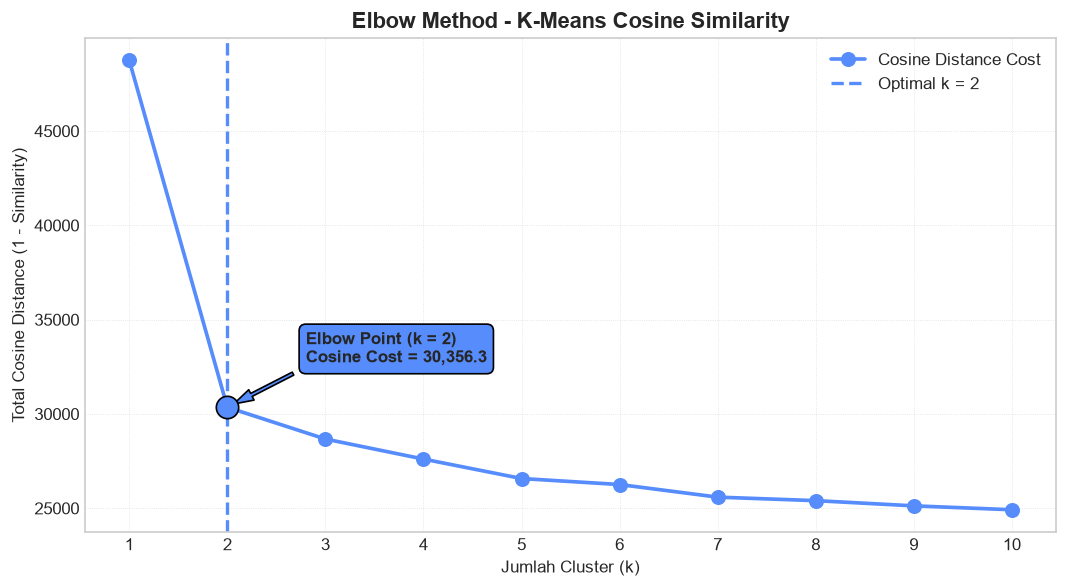

In [20]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    k_values,
    cosine_cost,
    marker='o',
    markersize=8,
    linewidth=2.2,
    label='Cosine Distance Cost'
)

plt.axvline(
    x=n_clusters,
    linestyle='--',
    linewidth=2,
    label=f'Optimal k = {n_clusters}'
)

plt.scatter(
    [n_clusters],
    [
        cosine_cost[
            n_clusters - 1
        ]
    ],
    s=180,
    zorder=5,
    edgecolor='black'
)

plt.title(
    'Elbow Method - '
    'K-Means Cosine Similarity',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel(
    'Jumlah Cluster (k)'
)

plt.ylabel(
    'Total Cosine Distance '
    '(1 - Similarity)'
)

plt.xticks(k_values)

plt.annotate(
    f'Elbow Point '
    f'(k = {n_clusters})\n'
    f'Cosine Cost = '
    f'{cosine_cost[n_clusters - 1]:,.1f}',

    xy=(
        n_clusters,
        cosine_cost[
            n_clusters - 1
        ]
    ),

    xytext=(
        n_clusters + 0.8,

        cosine_cost[
            n_clusters - 1
        ]
        + (
            max(cosine_cost)
            - min(cosine_cost)
        ) * 0.1
    ),

    arrowprops=dict(
        shrink=0.08,
        width=2,
        headwidth=7
    ),

    bbox=dict(
        boxstyle='round,pad=0.4'
    ),

    fontweight='bold'
)

plt.grid(
    True,
    linestyle=':',
    alpha=0.6
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        'elbow_cosine.png'
    ),
    dpi=300
)

plt.show()

3.2 Training K-Means Cosine Similarity

In [21]:
tracemalloc.start()

start_time = time.perf_counter()

X_np = X_cosine.to_numpy()

max_iter = 300
tol = 1e-4

rng = np.random.RandomState(42)

initial_indices = rng.choice(
    len(X_np),
    size=n_clusters,
    replace=False
)

centroids = X_np[
    initial_indices
].copy()

for iteration in range(
    1,
    max_iter + 1
):

    # Assignment
    similarities = (
        X_np
        @ centroids.T
    )

    similarities = np.clip(
        similarities,
        -1.0,
        1.0
    )

    labels = np.argmax(
        similarities,
        axis=1
    )

    # Update Centroid
    new_centroids = (
        centroids.copy()
    )

    for cluster_id in range(
        n_clusters
    ):

        cluster_points = X_np[
            labels == cluster_id
        ]

        if len(cluster_points) > 0:

            center = np.mean(
                cluster_points,
                axis=0
            )

            center_norm = (
                np.linalg.norm(
                    center
                )
            )

            if center_norm > 0:

                new_centroids[
                    cluster_id
                ] = (
                    center
                    / center_norm
                )

    # Convergence
    center_similarity = np.sum(
        new_centroids
        * centroids,
        axis=1
    )

    center_similarity = np.clip(
        center_similarity,
        -1.0,
        1.0
    )

    shift = np.max(
        1 - center_similarity
    )

    centroids = new_centroids

    if shift < tol:
        break

In [22]:
similarities = (
    X_np
    @ centroids.T
)

similarities = np.clip(
    similarities,
    -1.0,
    1.0
)

labels = np.argmax(
    similarities,
    axis=1
)

best_similarity = np.max(
    similarities,
    axis=1
)

cosine_objective = np.sum(
    1 - best_similarity
)

mean_cosine_similarity = (
    np.mean(
        best_similarity
    )
)

runtime = (
    time.perf_counter()
    - start_time
)

current_memory, peak_memory = (
    tracemalloc.get_traced_memory()
)

tracemalloc.stop()

peak_memory_mb = (
    peak_memory
    / (1024 ** 2)
)

iterations = iteration

df[
    'KMeans_Cluster'
] = labels

In [23]:
print(
    f'Runtime     : '
    f'{runtime:.5f} detik'
)

print(
    f'Iterations  : '
    f'{iterations}'
)

print(
    f'Cosine Cost : '
    f'{cosine_objective:.2f}'
)

print(
    f'Mean Cosine Similarity : '
    f'{mean_cosine_similarity:.4f}'
)

print(
    f'Peak Memory : '
    f'{peak_memory_mb:.2f} MB'
)

Runtime     : 0.18952 detik
Iterations  : 7
Cosine Cost : 30356.33
Mean Cosine Similarity : 0.3929
Peak Memory : 13.63 MB


4. Evaluasi

4.1 Silhouette Score

In [24]:
silhouette = float(
    silhouette_score(
        X_cosine,
        labels,
        metric='cosine'
    )
)

print(
    f'Silhouette Score: '
    f'{silhouette:.4f}'
)

Silhouette Score: 0.2574


4.2 Davies-Bouldin Index

In [25]:
db_index = float(
    davies_bouldin_score(
        X_cosine,
        labels
    )
)

print(
    f'Davies-Bouldin Index: '
    f'{db_index:.4f}'
)

Davies-Bouldin Index: 2.3324


4.3 Calinski-Harabasz Index

In [26]:
ch_index = float(
    calinski_harabasz_score(
        X_cosine,
        labels
    )
)

print(
    f'Calinski-Harabasz Index: '
    f'{ch_index:.2f}'
)

Calinski-Harabasz Index: 9093.79


4.4 Distribusi Cluster

In [27]:
cluster_distribution = (
    df['KMeans_Cluster']
    .value_counts()
    .sort_index()
)

cluster_distribution

KMeans_Cluster
0    25768
1    24232
Name: count, dtype: int64

4.5 Ringkasan Evaluasi

In [28]:
model_summary = pd.DataFrame([{
    'Model':
        'K-Means Cosine Similarity',

    'Distance Metric':
        'Cosine Distance '
        '(1 - Cosine Similarity)',

    'Jumlah Cluster':
        n_clusters,

    'Silhouette Score (↑)':
        round(
            silhouette,
            4
        ),

    'Davies-Bouldin Index (↓)':
        round(
            db_index,
            4
        ),

    'Calinski-Harabasz Index (↑)':
        round(
            ch_index,
            2
        ),

    'Execution Time (s) (↓)':
        round(
            runtime,
            5
        ),

    'Iterations (↓)':
        iterations,

    'Objective Value '
    '(Cosine Distance) (↓)':
        round(
            cosine_objective,
            2
        ),

    'Alokasi Memori (MB)':
        round(
            peak_memory_mb,
            2
        )
}])

model_summary

,Model,Distance Metric,Jumlah Cluster,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑),Execution Time (s) (↓),Iterations (↓),Objective Value (Cosine Distance) (↓),Alokasi Memori (MB)
0,K-Means Cosine Similarity,Cosine Distance (1 - Cosine Similarity),2,0.2574,2.3324,9093.79,0.18952,7,30356.33,13.63


4.6 Export Hasil

In [29]:
excel_path = os.path.join(
    OUTPUT_DIR,
    'evaluasi_kmeans_cosine.xlsx'
)

df_clustered = df.copy()

df_clustered[
    'KMeans_Cluster'
] = labels

with pd.ExcelWriter(
    excel_path,
    engine='openpyxl'
) as writer:

    model_summary.to_excel(
        writer,
        sheet_name='Ringkasan_Evaluasi',
        index=False
    )

    df_clustered.to_excel(
        writer,
        sheet_name='Data_Terklaster',
        index=False
    )

print(
    f'Hasil disimpan ke: '
    f'{excel_path}'
)

Hasil disimpan ke: outputKmeansCosine\evaluasi_kmeans_cosine.xlsx


5. Reduksi Dimensi PCA

5.1 PCA

In [30]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_cosine
)

centroids_pca = pca.transform(
    centroids
)

5.2 Visualisasi Hasil Klaster

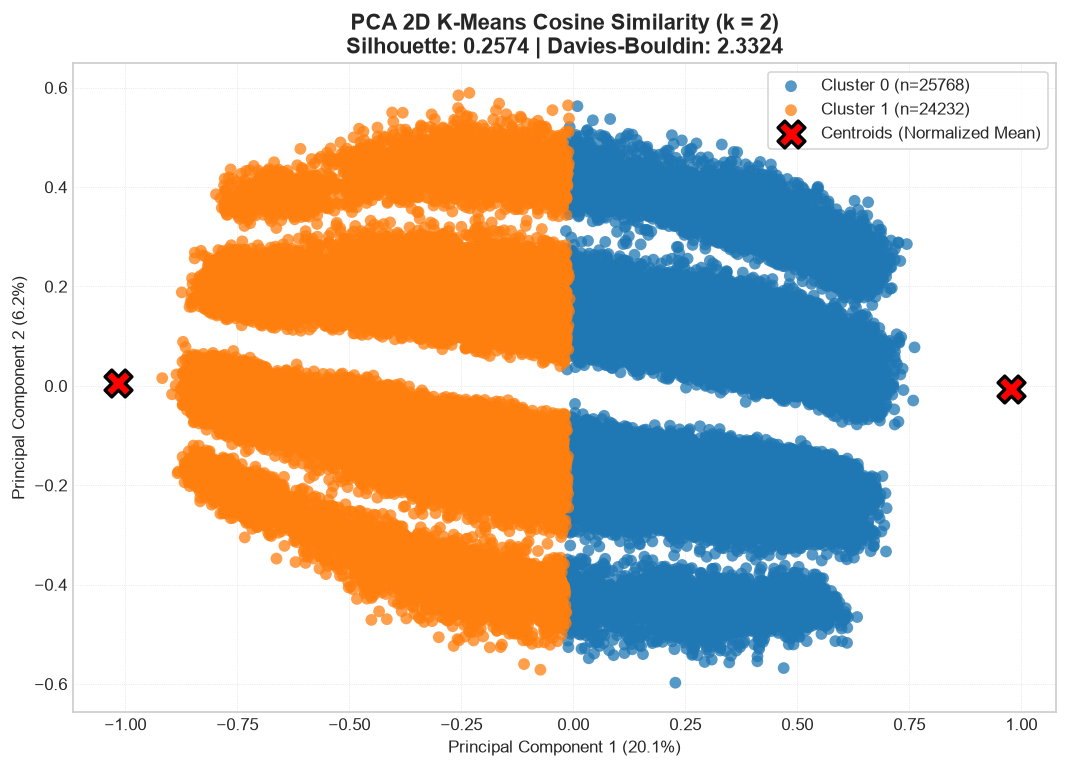

In [31]:
plt.figure(
    figsize=(9, 6.5)
)

palette = sns.color_palette(
    'tab10',
    n_clusters
)

for k in range(
    n_clusters
):

    mask = labels == k

    plt.scatter(
        X_pca[
            mask,
            0
        ],

        X_pca[
            mask,
            1
        ],

        color=palette[k],

        label=(
            f'Cluster {k} '
            f'(n={np.sum(mask)})'
        ),

        alpha=0.75,
        s=50,
        edgecolors='none'
    )

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],

    marker='X',
    s=260,
    c='red',

    edgecolor='black',
    linewidth=2,

    label=(
        'Centroids '
        '(Normalized Mean)'
    ),

    zorder=10
)

plt.title(
    f'PCA 2D '
    f'K-Means Cosine Similarity '
    f'(k = {n_clusters})\n'

    f'Silhouette: '
    f'{silhouette:.4f} | '

    f'Davies-Bouldin: '
    f'{db_index:.4f}',

    fontsize=13,
    fontweight='bold'
)

plt.xlabel(
    'Principal Component 1 '
    f'('
    f'{pca.explained_variance_ratio_[0] * 100:.1f}%'
    f')'
)

plt.ylabel(
    'Principal Component 2 '
    f'('
    f'{pca.explained_variance_ratio_[1] * 100:.1f}%'
    f')'
)

plt.grid(
    True,
    linestyle=':',
    alpha=0.6
)

plt.legend(
    frameon=True,
    loc='best'
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        'cluster_cosine.png'
    ),
    dpi=300
)

plt.show()

6. Analisis

6.1 Profil Cluster

In [32]:
df_analysis = X.copy()

df_analysis[
    'KMeans_Cluster'
] = labels

cluster_profile = (
    df_analysis
    .groupby(
        'KMeans_Cluster'
    )
    .mean()
)

cluster_profile

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,,
0,41.444112,6276.549497,36.983274,5.512914,5.508539,7.347788,20.292539,20.656586,79.581703,79.740647,...,0.162488,1.502484,0.49154,0.493985,0.496934,0.000000,0.495886,0.504944,1.513699,0.084213
1,41.452508,6224.411884,53.413792,5.484308,5.499993,6.624895,61.883216,61.809965,38.399157,37.733080,...,1.294776,1.515063,0.50033,0.502600,0.506685,0.278062,0.501032,0.503521,1.498019,1.361671


6.2 Perbandingan Cluster dengan Burnout Risk

In [33]:
comparison = pd.crosstab(
    df['KMeans_Cluster'],
    df['Burnout_Risk']
)

comparison

comparison_percentage = pd.crosstab(
    df['KMeans_Cluster'],
    df['Burnout_Risk'],
    normalize='index'
) * 100

comparison_percentage.round(2)

Burnout_Risk,High,Low,Moderate
KMeans_Cluster,,,
0,0.00,91.58,8.42
1,40.65,7.31,52.04


6.3 Analisis Centroid

In [34]:
centroid_cosine = pd.DataFrame(
    centroids,
    columns=X.columns
)

centroid_cosine.index.name = (
    'Cluster'
)

centroid_cosine

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
Cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.000256,0.004002,-0.240238,0.002334,0.000265,0.091882,-0.348852,-0.341633,0.348413,0.348783,...,-0.356010,-0.002317,-0.003919,-0.004229,-0.004981,-0.184814,-0.002140,0.000284,0.003077,-0.360332
1,0.000419,-0.004753,0.249366,-0.003739,-0.000952,-0.094886,0.354736,0.347045,-0.354679,-0.354431,...,0.353844,0.001970,0.004005,0.005048,0.004299,0.115544,0.001838,-0.000136,-0.004088,0.353171
